Import all the necessary modules and load the Data Set.

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load the dataset
data = pd.read_csv('parkingLot.csv')

# Display the first few rows of the dataset
# print(data.head())


Data Processing using pandas and Data cleaning

In [105]:
# Step 1: Clean the dataset
# Convert 'timestamp' to datetime
data['timestamp'] = pd.to_datetime(data['timestamp'])

# Remove duplicates
data.drop_duplicates(inplace=True)

# Step 2: Filter out entries between 12 AM and 5 AM for both cameras
data = data[(data['timestamp'].dt.hour >= 5) & (data['timestamp'].dt.hour < 24)]

# Step 3: Count the number of vehicles entering per day
# Filter to only the entry camera
entry_data = data[data['camera_id'] == 1].copy()

# Create a new column for date using .loc to avoid SettingWithCopyWarning
entry_data.loc[:, 'date'] = entry_data['timestamp'].dt.date

# Count total entries per day
daily_entries = entry_data.groupby('date').size().reset_index(name='total_entries')

# Ensure the 'date' column is in datetime format
daily_entries['date'] = pd.to_datetime(daily_entries['date'])

# Sort the date columns to ensure chronological order
daily_entries.sort_values(by='date', inplace=True)

# Create a Sunday indicator (1 for Sundays, 0 for other days)
daily_entries['is_sunday'] = daily_entries['date'].dt.dayofweek == 6  # 6 indicates Sunday in pandas

# Convert the is_sunday column to integers (1 for True, 0 for False)
daily_entries['is_sunday'] = daily_entries['is_sunday'].astype(int)

# Show daily entries
print("Daily vehicle entries:\n", daily_entries)


Daily vehicle entries:
          date  total_entries  is_sunday
0  2024-09-12            886          0
1  2024-09-13            809          0
2  2024-09-14            863          0
3  2024-09-15           1073          1
4  2024-09-16            843          0
..        ...            ...        ...
58 2024-11-09            867          0
59 2024-11-10            944          1
60 2024-11-11            828          0
61 2024-11-12            806          0
62 2024-11-13            781          0

[63 rows x 3 columns]


The differenced data required to verify whether d = 1 yields a stationary series

In [106]:
# Create the differenced series
daily_entries['differenced'] = daily_entries['total_entries'].diff()

# drop the first row since it will have NaN value after differencing
differenced_entries = daily_entries.dropna()

# Display the differenced entries
# print("Differenced daily vehicle entries:\n", differenced_entries[['date', 'total_entries', 'differenced']])

Split the given data into training and testing sets. To find the value of d in our sarima we have plotted and observed the series as well as its difference series.(We have also conformed with the adfuller function).\
We have concluded that d = 1 as the differenced values yielded a better stationary series

In [107]:
# Split the data into train and test sets
train_size = len(daily_entries) - 14
train, test = daily_entries[:train_size], daily_entries[train_size:]

# Check the sizes of train and test sets
print(f"\nTrain set size: {len(train)}, Test set size: {len(test)}")
# print(test)


# Below is the verification metric
# from statsmodels.tsa.stattools import adfuller

# # Assuming 'daily_entries' is your DataFrame or Series with daily entries
# result = adfuller(daily_entries['total_entries'])  # Adjust according to your data structure

# print('ADF Statistic:', result[0])
# print('p-value:', result[1])
# print('Critical Values:')
# for key, value in result[4].items():
#     print(f'   {key}: {value:.3f}')


Train set size: 49, Test set size: 14


We are implementing the SARIMA model to train and make predictions. We use d = 1. \
We predict optimal p and q by observing the ACF and PACF plots as well as through experimentation(observing MASE for various values)

In [108]:
# SARIMAX model with weekly seasonality and Sunday indicator as an exogenous variable
sarima_model = SARIMAX(train['total_entries'], 
                       exog=train[['is_sunday']],    # Include Sunday indicator
                       order=(4, 1, 3), 
                       seasonal_order=(1, 1, 1, 6),  # Weekly seasonal with 6 days as we observe a little higher demand on weekends
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

# Fit the model
sarima_results = sarima_model.fit(method='powell')

# Forecast the next 7 days using the Sunday indicator as exogenous variable
forecast_values = sarima_results.get_forecast(steps=14, exog=test[['is_sunday']])
forecast = forecast_values.predicted_mean

# print("\nForecast for total vehicle entries for the next 7 days:")
# print(forecast)

# # Example of fitting the ARIMA model with tuned parameters
# p = 4  # Adjust based on PACF
# d = 1  # Adjust based on differencing results
# q = 3  # Adjust based on ACF

# model = ARIMA(train['total_entries'], order=(p, d, q))
# model_fit = model.fit()

# # Forecast for the next 7 days
# forecast = model_fit.forecast(steps=14)
# print(forecast)

Optimization terminated successfully.
         Current function value: 3.724381
         Iterations: 7
         Function evaluations: 764


Calculate the value of MAPE and MASE for our model based on the forcasted and actual test data \
SARIMA Model - MAPE: 0.0452, MASE: 0.6749

In [109]:
# Calculate MAE for the ARIMA model predictions
mae_model = mean_absolute_error(test['total_entries'], forecast)

# Calculate MAPE
mape_arima = mean_absolute_percentage_error(test['total_entries'], forecast)

# Calculate the naive forecast using the last observation method
naive_forecast = test['total_entries'].shift(1)  # Shift to simulate naive forecasting
# Skip the first NaN value in MAE calculation
mae_naive = mean_absolute_error(test['total_entries'][1:], naive_forecast[1:])  

# #Alternatively, if you want to use the mean of the training set as a naive forecast
# naive_forecast_mean = train['total_entries'].mean()
# naive_forecast_values = [naive_forecast_mean] * len(test)
# mae_naive = mean_absolute_error(test['total_entries'], naive_forecast_values)

# Calculate MASE
mase_arima = mae_model / mae_naive

# Print the results
print(f"SARIMA Model - MAPE: {mape_arima:.4f}, MASE: {mase_arima:.4f}")

SARIMA Model - MAPE: 0.0509, MASE: 0.7600


Plot the given time series to deduce/ get an idea about various properties such as seasonality and trend 

In [110]:
plt.figure(figsize=(12, 6))

# Plotting the total entries over time
plt.plot(daily_entries['date'], daily_entries['total_entries'], marker='o', linestyle='-', color='blue', markersize=3)

# Adding titles and labels
plt.title('Total Vehicle Entries Over Time per day', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Entries', fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)

plt.tight_layout()
plt.savefig('plot10.png')
plt.close()

Plot the difference series. Observe that this looks better and more stationary than the previous time series(d=0)

In [111]:
plt.figure(figsize=(12, 6))

# Plotting the total entries over time
plt.plot(differenced_entries['date'], differenced_entries['differenced'], marker='o', linestyle='-', color='blue', markersize=3)

# Adding titles and labels
plt.title('Difference of Total Vehicle Entries Over Time per day', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Total Entries', fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)

plt.tight_layout()
plt.savefig('plot11.png')
plt.close()

We are plotting the ACF and PACF functions to get an idea about the degree of correlation and the values of p and q

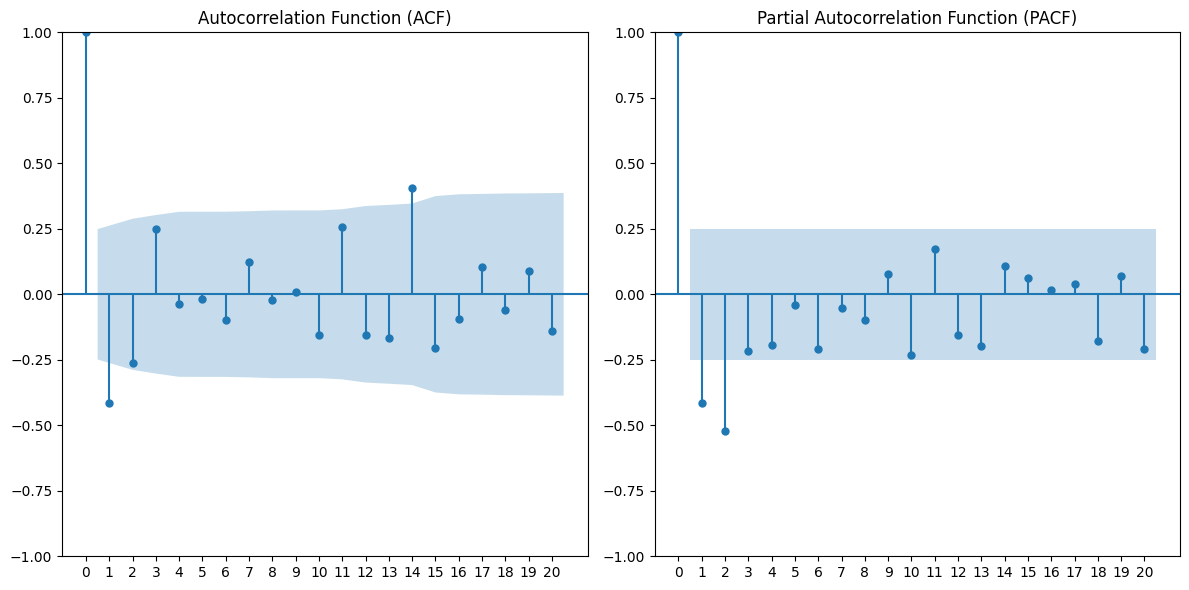

In [112]:
# Assuming 'train' is your training dataset with the 'total_entries' column
plt.figure(figsize=(12, 6))

# ACF Plot
plt.subplot(1, 2, 1)
plot_acf(differenced_entries['differenced'], lags=20, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')
plt.xticks(range(0, 21, 1))  # Set xticks to show every lag up to 20

# PACF Plot
plt.subplot(1, 2, 2)
plot_pacf(differenced_entries['differenced'], lags=20, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF)')
plt.xticks(range(0, 21, 1))  # Set xticks to show every lag up to 20

plt.tight_layout()
plt.show()


Let us now use our ARIMA model to predict the number of vehicles entering the parking lot in the next 7 days

In [113]:
# SARIMAX model with weekly seasonality and Sunday indicator as an exogenous variable
sarima_model_final = SARIMAX(daily_entries['total_entries'], 
                       exog=daily_entries[['is_sunday']],    # Include Sunday indicator
                       order=(4, 1, 3), 
                       seasonal_order=(1, 1, 1, 6),  # Weekly seasonal with 6 days as we observe a little higher demand on weekends
                       enforce_stationarity=False, 
                       enforce_invertibility=False)

# Fit the model
sarima_results_final = sarima_model_final.fit(method='powell')


# Forecast the next 7 days using the Sunday indicator as exogenous variable
# Exogenous variable for the next 7 days starting from November 14, 2024
exog_forecast = [0, 0, 0, 1, 0, 0, 0]  # Corresponding to Nov 14 to Nov 20
forecast_values_final = sarima_results_final.get_forecast(steps=7, exog=exog_forecast)
forecast_final = forecast_values_final.predicted_mean

# The final forecast for the next 7 days
print(forecast_final)

Optimization terminated successfully.
         Current function value: 4.055593
         Iterations: 10
         Function evaluations: 1143
63    840.392345
64    862.900817
65    813.441560
66    923.822111
67    840.294375
68    813.022432
69    857.036687
Name: predicted_mean, dtype: float64
